# Intelligent Automation 2026/27- Assignment 1

To be delivered until 2026-10-09 23:59:59.

**Submission Notes**:
- Create a folder in your group's GitHub repository to solve this assignment. Copy this notebook into that folder.
- You should commit regularly to your repository the answers to the questions in this notebook. If you do not, your grade will be penalized by 1/20 points.
- After running the entire notebook (including graphs and outputs), save the notebook as a .pdf file, by going to File - Print - Destination: Save as PDF.
- Create a .zip file containing both the .ipynb file (the notebook itself) and the .pdf and submit it in Fénix.

# Problem description

The dataset for this assignment contains information on students from two Portuguese secondary schools enrolled in a mathematics course.
Each row corresponds to one student and includes demographic and family background variables (e.g., basic personal and household characteristics), school-related variables (e.g., school context, study habits, past failures), behavioral and lifestyle indicators (e.g., free time, going out, alcohol use), and the grades for the three school periods, on a 0–20 scale.

The goal is to predict the performance of the students in the final period.
First, the problem will be approached as a classification task, predicting whether a student will pass (G3 >= 10) or fail (G3 < 10) the course.
Then, the problem will be approached as a regression task, predicting the actual final grade (G3).

A detailed description of all variables (family context, behavioral, school performance, etc.) is provided in the file `feature_description.txt`.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, fbeta_score, mean_squared_error, r2_score)
sns.set_theme(style="whitegrid")

# Part 1 - Data exploration **(4.00)**

##### **1.1.** Load the dataset from the CSV file `mathematics_grades.csv`. **(0.25)**

In [13]:
dados = pd.read_csv("mathematics_grades.csv")
print(dados.shape)
dados.head()

(357, 34)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,failed
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,True
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,True
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,False
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,False
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,False


##### **1.2.** Identify the feature types of each variable in the dataset. **(1.50)**

In [18]:
for coluna in dados.columns:
    print(coluna, "->", dados[coluna].dtype)

school -> object
sex -> object
age -> int64
address -> object
famsize -> object
Pstatus -> object
Medu -> int64
Fedu -> int64
Mjob -> object
Fjob -> object
reason -> object
guardian -> object
traveltime -> int64
studytime -> int64
failures -> int64
schoolsup -> object
famsup -> object
paid -> object
activities -> object
nursery -> object
higher -> object
internet -> object
romantic -> object
famrel -> int64
freetime -> int64
goout -> int64
Dalc -> int64
Walc -> int64
health -> int64
absences -> int64
G1 -> int64
G2 -> int64
G3 -> int64
failed -> bool


##### **1.3** Check if the dataset has missing values. If so, discard any row that has a missing value. **(0.25)**

In [19]:
# Check for missing values
print(dados.isnull().sum())

# Remove rows containing missing values
dados = dados.dropna()

# Check the new shape
print(dados.shape)

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
failed        0
dtype: int64
(357, 34)


##### **1.4.** Make a pairplot of the numerical variables, colored by the `failed` variable. **(0.50)**

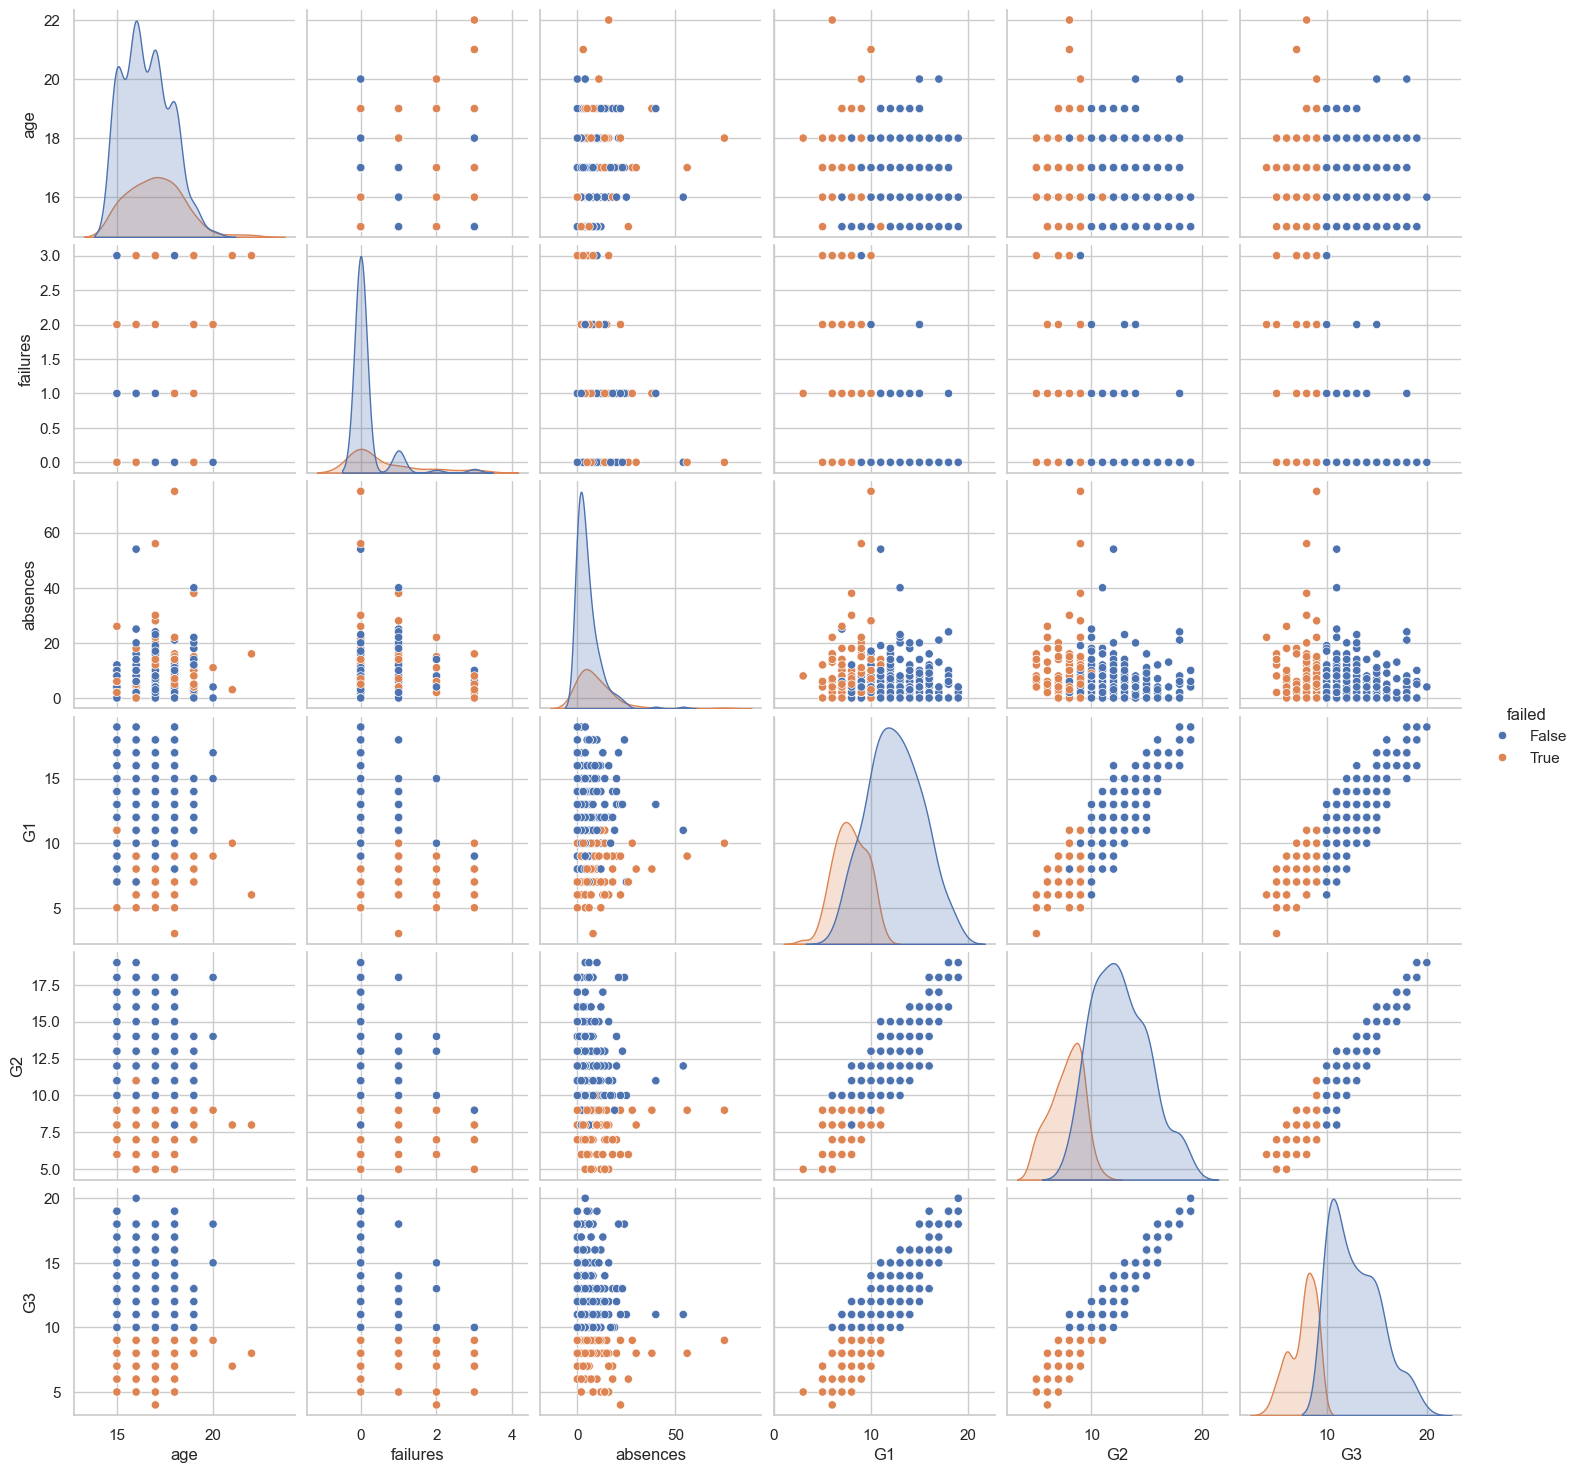

In [21]:
numerical_vars = ['age', 'failures', 'absences', 'G1', 'G2', 'G3']

sns.pairplot(
    dados,
    vars=numerical_vars,
    hue='failed'
)

plt.show()

##### **1.5.** Make bar plots for each categorical variable, showing the counts for each category, colored by the `failed` variable. **(0.50)**

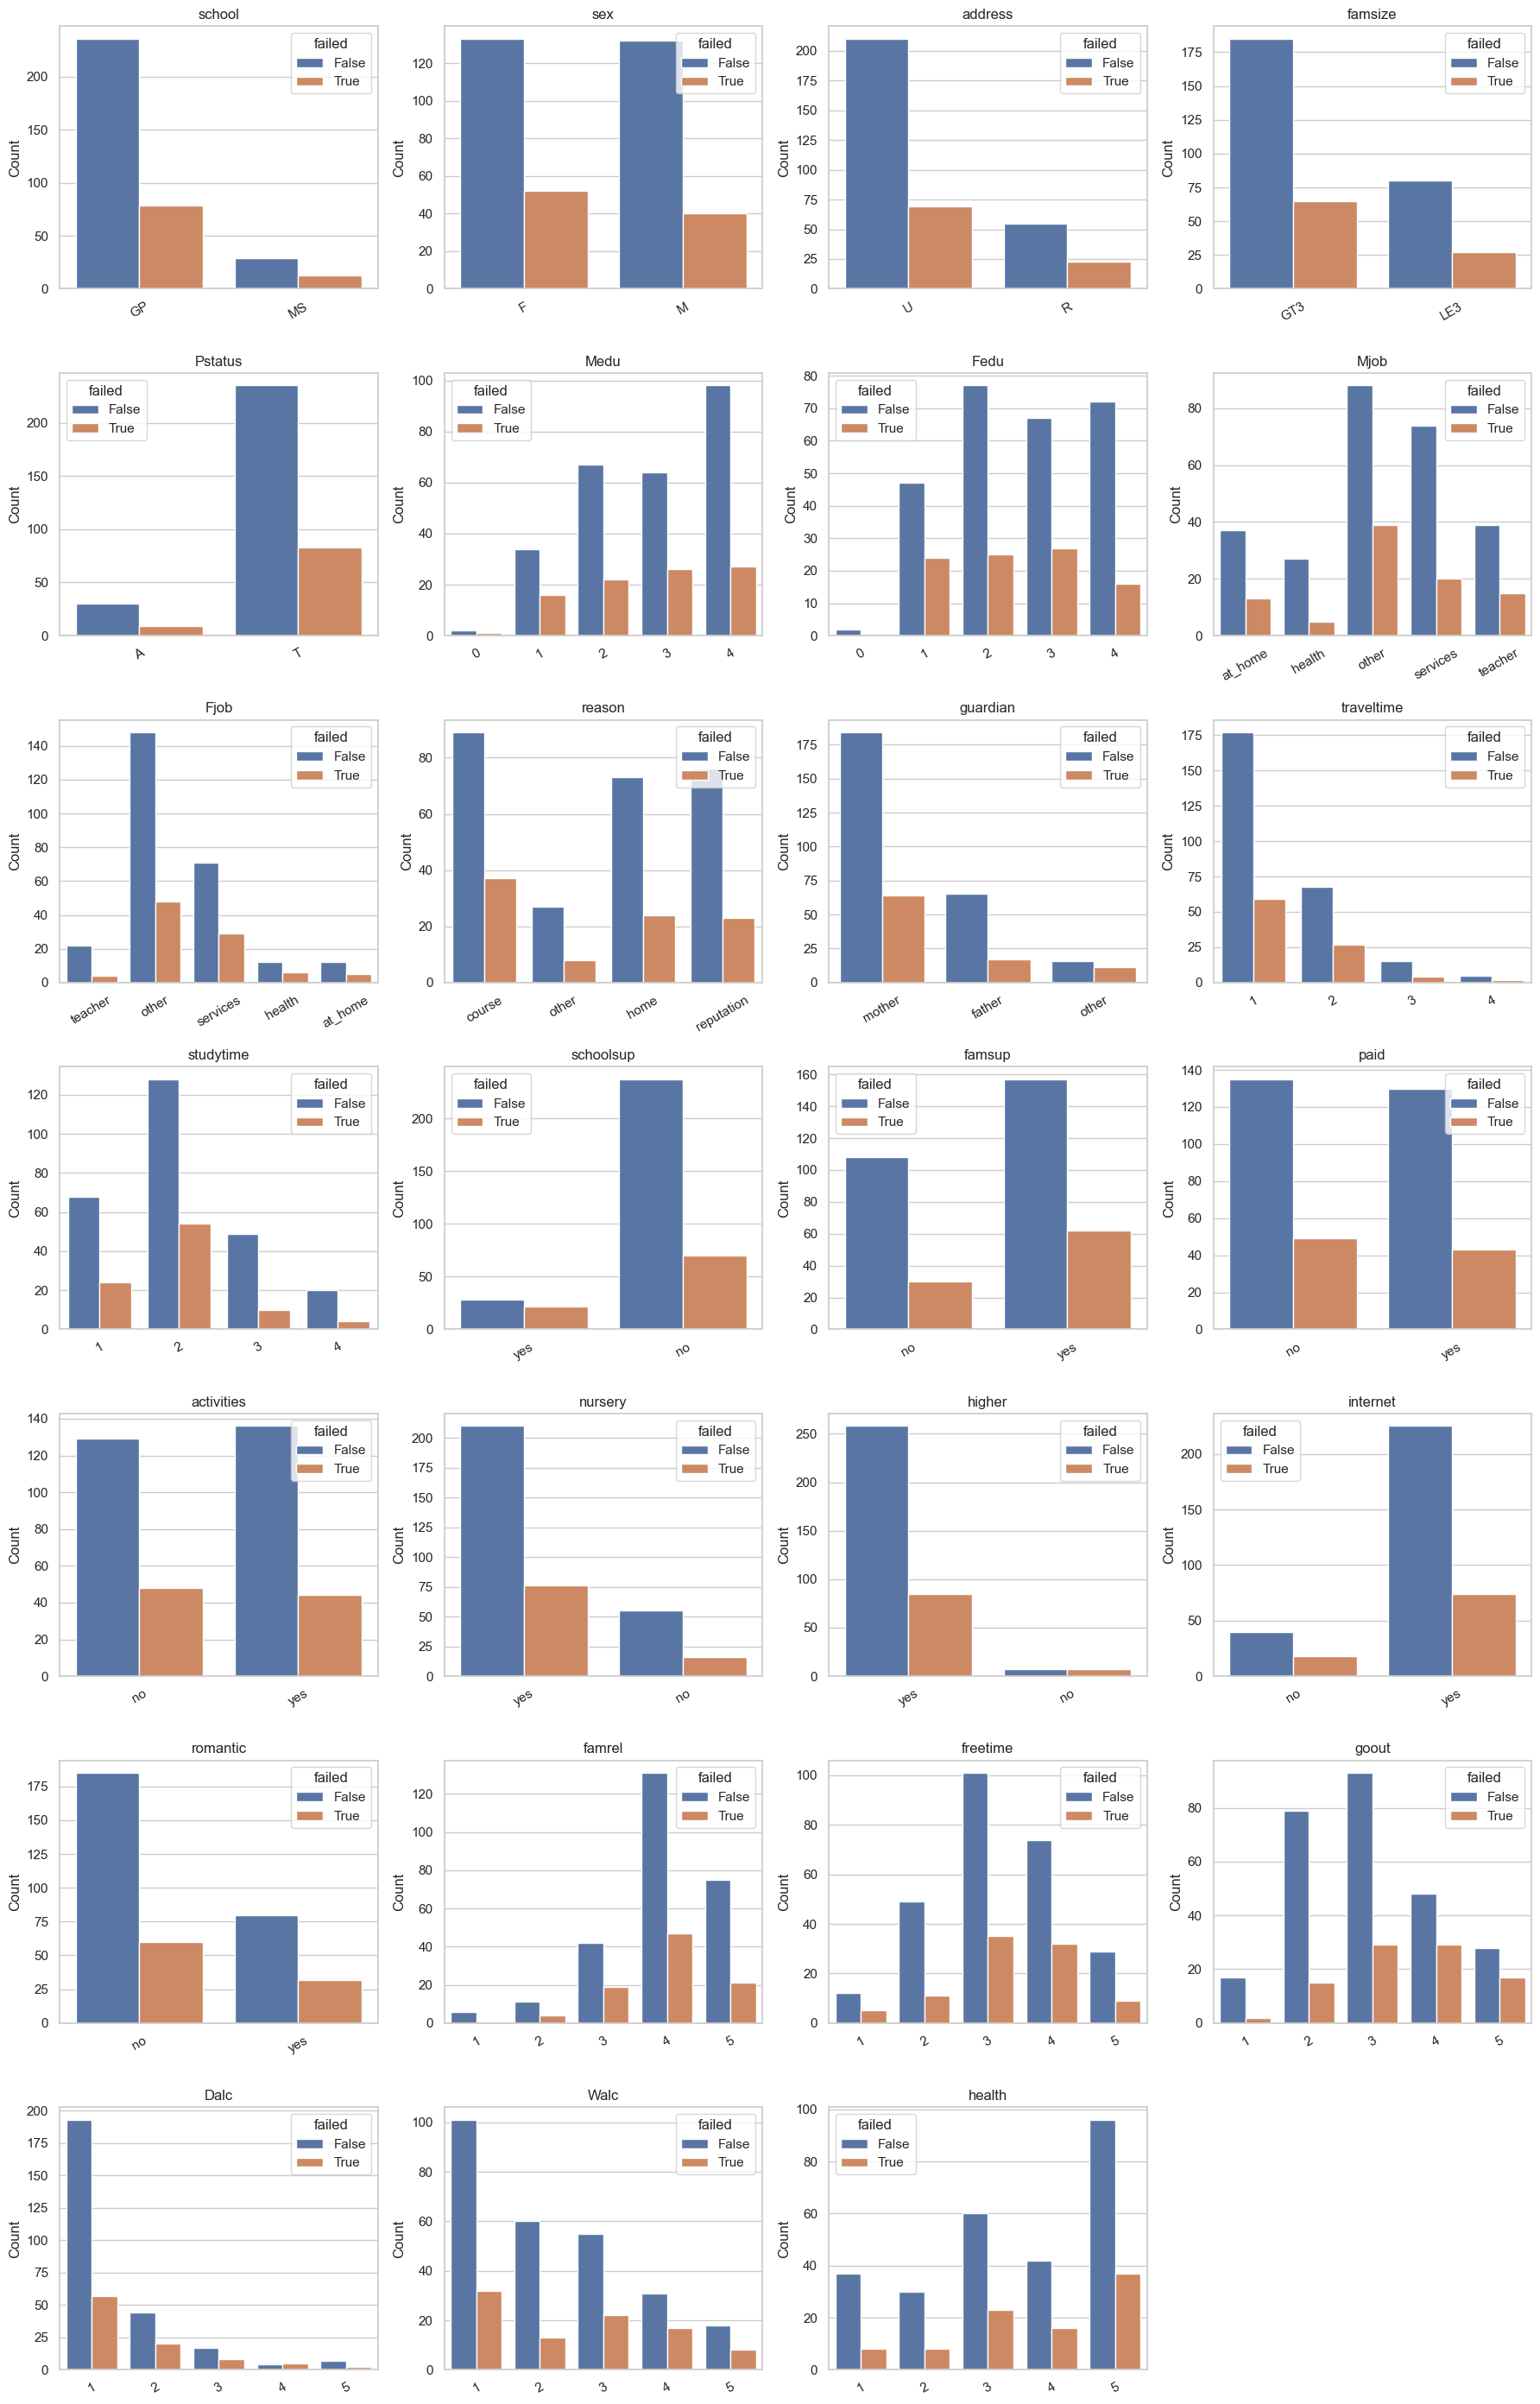

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

categorical_vars = [
    'school', 'sex', 'address', 'famsize', 'Pstatus',
    'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian',
    'traveltime', 'studytime',
    'schoolsup', 'famsup', 'paid', 'activities',
    'nursery', 'higher', 'internet', 'romantic',
    'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health'
]

# Number of plots per row
n_cols = 4
n_rows = math.ceil(len(categorical_vars) / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, var in enumerate(categorical_vars):
    sns.countplot(
        data=dados,
        x=var,
        hue='failed',
        ax=axes[i]
    )
    
    axes[i].set_title(var)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    
    # Rotate labels when necessary
    axes[i].tick_params(axis='x', rotation=30)

# Remove empty subplots
for i in range(len(categorical_vars), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

##### **1.6.** In each school, how many students live in a rural area and do not have internet access at home? **(0.50)**

In [23]:
result = (
    dados[
        (dados['address'] == 'R') &
        (dados['internet'] == 'no')
    ]
    .groupby('school')
    .size()
    .reindex(dados['school'].unique(), fill_value=0)
)

print(result)

school
GP    17
MS     7
dtype: int64


##### **1.7.** Split the dataset into a training set (80%) and a test set (20%). **(0.50)**

In [25]:
from sklearn.model_selection import train_test_split

# Features and target
X = dados.drop('failed', axis=1)
y = dados['failed']

# Split: 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=2026
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (285, 33)
Test set: (72, 33)


# Part 2 - Classification **(7.50)**

##### You'll start by approaching the problem as a classification task, predicting whether a student will pass (G3 >= 10) or fail (G3 < 10) the course. Consider the variable `failed` as the target variable.

##### **2.1.** Which performance metric do you think are most important for this prediction task, and why? Justify your answer in the context of supporting students who may struggle academically. **(2.00)**

##### **2.2.** Build a logistic regression model to predict whether a student will pass or fail the course, using as predictor the feature `absences`. Evaluate the performance of the model on the test set using a confusion matrix, accuracy, precision, recall, f1-score and the metric you selected in question 2.1. **(0.50)**

In [28]:
# Predictor and target
X = dados[['absences']]
y = dados['failed']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create and train the logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Confusion Matrix:
[[51  2]
 [18  1]]
Accuracy:  0.7222
Precision: 0.3333
Recall:    0.0526
F1-score:  0.0909


##### **2.3.** The model you built in question 2.2 likely does not perform very well. Explain why this is the case, considering the distribution of the predictor and the response. How can you improve the model? **(2.00)**

##### **2.4.** Consider now the variable `studytime` as the predictor and assume it is numerical. Build a logistic regression model to predict whether a student will pass or fail the course. Evaluate the performance of the model on the test set using a confusion matrix, accuracy, precision, recall, f1-score and the metric you selected in question 2.1. **(0.50)**

Note: Use `sklearn.linear_model.LogisticRegression(class_weight='balanced')` for your logistic regression model.

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Predictor and target
X = dados[['studytime']]
y = dados['failed']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Logistic regression with balanced class weights
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Confusion Matrix:")
print(cm)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Confusion Matrix:
[[41 12]
 [15  4]]
Accuracy:  0.6250
Precision: 0.2500
Recall:    0.2105
F1-score:  0.2286


##### **2.5.** Repeat question 2.4, but now considering `studytime` as a categorical variable. **(0.50)**

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Predictor and target
X = dados[['studytime']]
y = dados['failed']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Encode studytime as categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('studytime', OneHotEncoder(handle_unknown='ignore'), ['studytime'])
    ]
)

# Logistic regression with balanced class weights
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced'))
])

# Train
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Confusion Matrix:")
print(cm)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Confusion Matrix:
[[20 33]
 [ 1 18]]
Accuracy:  0.5278
Precision: 0.3529
Recall:    0.9474
F1-score:  0.5143


##### **2.6.** What is the difference between the two models you built in questions 2.4 and 2.5? Plot the predictions of each model over the range of `studytime` values in the test set. What are the advantages and disadvantages of each approach? **(2.00)**


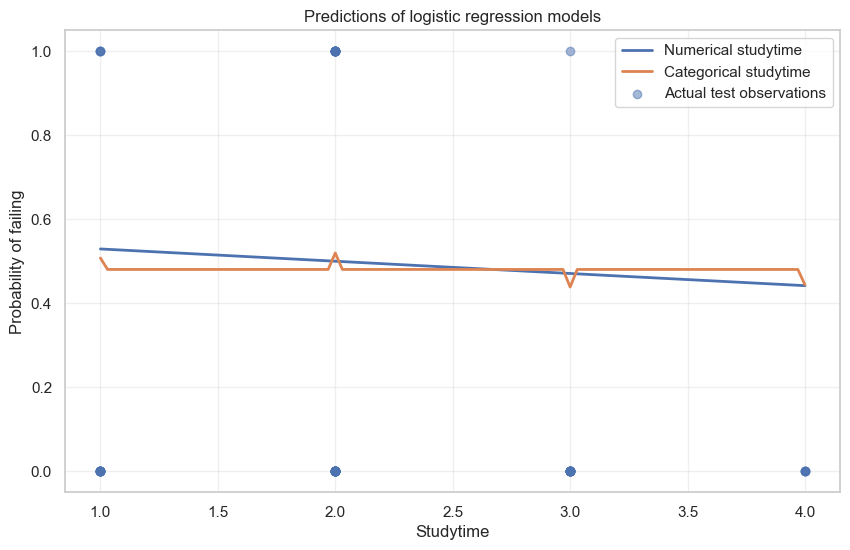

In [33]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# --------------------------------------------------
# 1. Train/test split
# --------------------------------------------------

X = dados[['studytime']]
y = dados['failed']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# --------------------------------------------------
# 2. Model from question 2.4
#    studytime considered numerical
# --------------------------------------------------

model_numeric = LogisticRegression(class_weight='balanced')

model_numeric.fit(X_train, y_train)

# --------------------------------------------------
# 3. Model from question 2.5
#    studytime considered categorical
# --------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ('studytime', OneHotEncoder(handle_unknown='ignore'), ['studytime'])
    ]
)

model_categorical = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced'))
])

model_categorical.fit(X_train, y_train)

# --------------------------------------------------
# 4. Values of studytime over the test-set range
# --------------------------------------------------

studytime_range = np.linspace(
    X_test['studytime'].min(),
    X_test['studytime'].max(),
    100
).reshape(-1, 1)

studytime_range_df = pd.DataFrame(
    studytime_range,
    columns=['studytime']
)

# Predictions: probability of failing
prob_numeric = model_numeric.predict_proba(
    studytime_range_df
)[:, 1]

prob_categorical = model_categorical.predict_proba(
    studytime_range_df
)[:, 1]

# --------------------------------------------------
# 5. Plot
# --------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    studytime_range,
    prob_numeric,
    label='Numerical studytime',
    linewidth=2
)

plt.plot(
    studytime_range,
    prob_categorical,
    label='Categorical studytime',
    linewidth=2
)

plt.scatter(
    X_test['studytime'],
    y_test.astype(int),
    alpha=0.5,
    label='Actual test observations'
)

plt.xlabel('Studytime')
plt.ylabel('Probability of failing')
plt.title('Predictions of logistic regression models')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Part 3 - Regression (3.50)

##### In this part of the assignment, you'll approach the problem as a regression task, predicting the actual final grade `G3`. Use the same training and test sets you created in Part 1.

##### **3.1.** Build a linear regression model to predict the final grade `G3`, using as predictor the feature `G2`. Evaluate the performance of the model on the test set using Mean Squared Error (MSE) and R-squared ($R^2$). **(0.50)**

In [34]:
# Predictor and target
X = dados[['G2']]
y = dados['G3']

# Use the same train/test split as in Part 1
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Build and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"R-squared: {r2:.4f}")

MSE: 0.6854
R-squared: 0.9289


##### **3.2.** Print the equation of the model you built in question 3.1. Plot the predictions of the model as a function of the inputs, along with the actual data points from the test set. Interpret the coefficients of the model. **(1.00)**


Model equation:
G3 = 0.2750 + (0.9897 × G2)


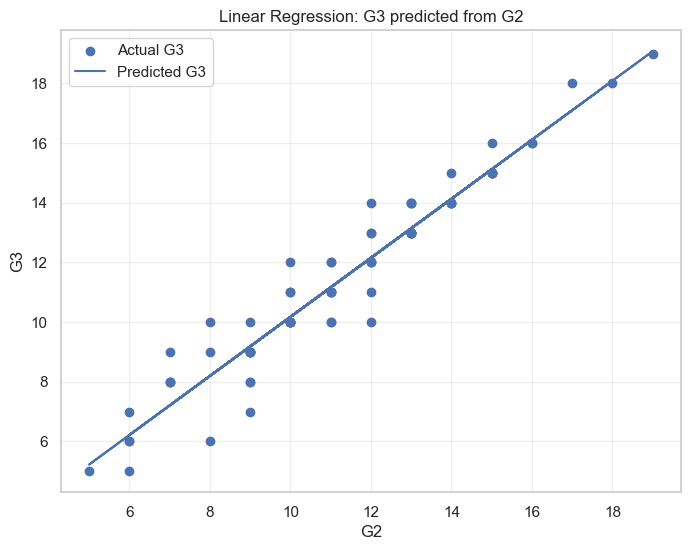

In [35]:
import matplotlib.pyplot as plt

# Coefficients
intercept = model.intercept_
coefficient = model.coef_[0]

# Print the equation
print(f"Model equation:")
print(f"G3 = {intercept:.4f} + ({coefficient:.4f} × G2)")

# Plot actual test data
plt.figure(figsize=(8, 6))

plt.scatter(
    X_test['G2'],
    y_test,
    label='Actual G3'
)

# Plot predictions
plt.plot(
    X_test['G2'],
    y_pred,
    label='Predicted G3'
)

plt.xlabel('G2')
plt.ylabel('G3')
plt.title('Linear Regression: G3 predicted from G2')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

##### **3.3.** Build a linear regression model to predict the final grade `G3`, using as predictors all features except the variables related to the grades (`G1`, `G2`, `G3`, `failed`). Explain the choices you made. Evaluate the performance of the model on the test set using Mean Squared Error (MSE) and R-squared ($R^2$). Plot the predicted vs actual values of `G3` for the test set. **(1.00)**

MSE: 7.6908
R-squared: 0.2017


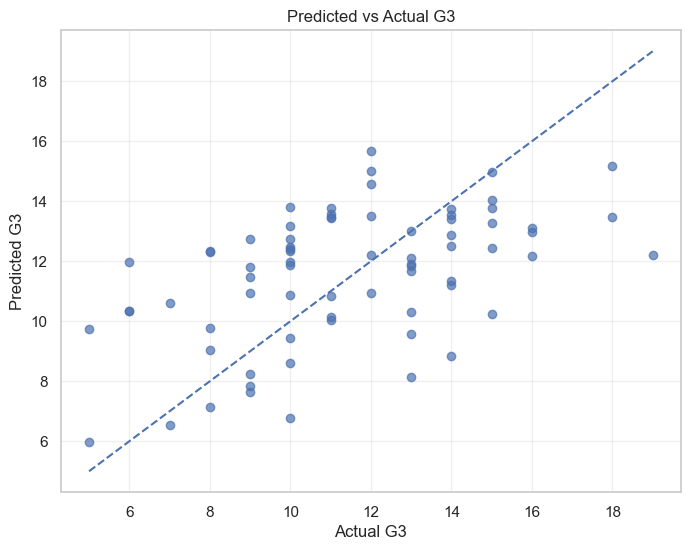

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Define predictors and target
# Remove all grade-related variables
X = dados.drop(['G1', 'G2', 'G3', 'failed'], axis=1)
y = dados['G3']

# 2. Use the same train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# 3. Identify categorical and numerical features
categorical_features = X_train.select_dtypes(
    include=['object', 'bool']
).columns

numerical_features = X_train.select_dtypes(
    exclude=['object', 'bool']
).columns

# 4. Preprocessing
# One-hot encode categorical variables
# Keep numerical variables unchanged
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical',
         OneHotEncoder(handle_unknown='ignore'),
         categorical_features),
        ('numerical',
         'passthrough',
         numerical_features)
    ]
)

# 5. Create the linear regression pipeline
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 6. Train the model
model.fit(X_train, y_train)

# 7. Predict G3 on the test set
y_pred = model.predict(X_test)

# 8. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"R-squared: {r2:.4f}")

# 9. Plot predicted vs actual values
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('Predicted vs Actual G3')
plt.grid(alpha=0.3)

plt.show()

##### **3.4.** In terms of application, what is the difference between building a model to predict student performance using the grades of the previous periods (as in question 3.1) versus using other features (as in question 3.3)? When would each approach be more appropriate? **(1.00)**

# Part 4 - Cross-validation (4.00)

##### **4.1.** Explain the concept of cross-validation and its importance in evaluating machine learning models. **(1.00)**

Cross-validation is a resampling technique in which the available data are repeatedly divided into training and validation subsets to estimate how well a model generalizes to unseen data.
Cross-validation is important for evaluating machine learning models for several reasons. First, it prevents optimistic bias, evaluating a model directly on the training observations (training error) consistently underestimates the true test error and fails to detect overfitting. Second, it is an alternative to a large held-out test set, when the available dataset is relatively small, holding out a large test set substantially reduces the data available for model fitting, whereas cross-validation provides a reliable estimate of the test error while leveraging all available data across iterations. Third, it supports model assessment and parameter tuning, since it provides a criterion to select the optimal model flexibility, tune parameters, and select the model with the best estimated test error.

##### **4.2.** Describe how K-fold cross-validation works. What values of K should be used? Justify. **(1.00)**

K-fold cross-validation works by randomly splitting the dataset of n observations into K mutually exclusive folds of approximately equal size. The model is evaluated over K iterations, where in each iteration a single fold is held out for validation while the remaining K-1 folds are used for training. The chosen error metric (such as MSE or misclassification rate) is computed on the held-out fold, and the overall cross-validation error CV(K) is obtained by averaging these results across all K iterations.
In practice, K=5 or K=10 are standard choices because they provide a good balance in the bias-variance tradeoff at a manageable computational cost. While setting K=n (LOOCV) minimizes bias, it trains models on almost identical data subsets, resulting in highly correlated validation estimates and high variance. On the other hand, very small values, such as K=2, introduce substantial pessimistic bias by using only half of the observations for training in each iteration. Using K=5 or K=10 keeps bias relatively low, reduces variance, and avoids the computational burden of fitting n separate models.

##### **4.3.** Explain how K-Fold cross-validation should be done to choose the classification threshold for the logistic regression model of Part 2. **(2.00)**

By default, logistic regression classifies an observation as positive when the predicted probability satisfies p^(X)≥0.5. However, in our context, identifying students at risk of failing (failed=1) is intended to provide early academic support, making a False Negative (missing a struggling student) much more harmful than a False Positive (offering unnecessary help).
To choose an optimal threshold, we first define a candidate grid of values, such as 0.05 to 0.95, along with a metric that penalizes False Negatives while still accounting for False Positives, such as the F2-score (recall alone would be trivially maximized by predicting every student as failed). We then split the training data into K stratified folds to preserve the proportion of failing and non-failing students. Across K iterations, the model is trained on K−1 folds and used to predict probabilities for the remaining validation fold. Any preprocessing or feature transformations should be performed using only the training portion of each fold to avoid data leakage.
Within each validation fold, we convert the predicted probabilities into binary predictions using every candidate threshold and compute the evaluation metric. Finally, we average the metric scores across all K folds for each threshold and select the value that maximizes the chosen metric. Since False Negatives are more costly in this context, the optimal threshold may be below 0.5, increasing the model's sensitivity to students at risk of failing. The final logistic regression model is then fitted on the entire training set, using the selected threshold, and evaluated on the held-out test set.

# Part 5 - GitHub (1.00)

##### **5.1.** Describe how your group used GitHub to track changes throughout the project and explain why maintaining a clear change history is important in data analysis and machine learning work. **(1.00)**

Throughout the project, our group used a private GitHub repository with the team members as collaborators. We worked on separate branches, regularly pulled updates, committed changes with clear messages, and pushed our work to the repository. We also committed each completed part of the notebook, allowing the repository history to track our progress. Merge conflicts were manually resolved before merging changes into the main branch.